<h1 style="color: skyblue; font-size: 60px;">
  <em><strong>Trabajo Integrador Final</strong></em>
</h1>

Autrores:
- Juan Acosta
- Florencia Sosa
- Joaquín Sánchez

***Fecha: 4/07/2025***


# <span style="color: teal;">***Introducción***</span>

## <span style="color: teal;">***Objetivo***</span>


- Implementar una librería para el procesamiento, análisis y visualización de señales fisiológicas como EEG, EMG y ECG, utilizando Programación Orientada a Objetos (POO).

> #### **Diagrama de Clases UML**


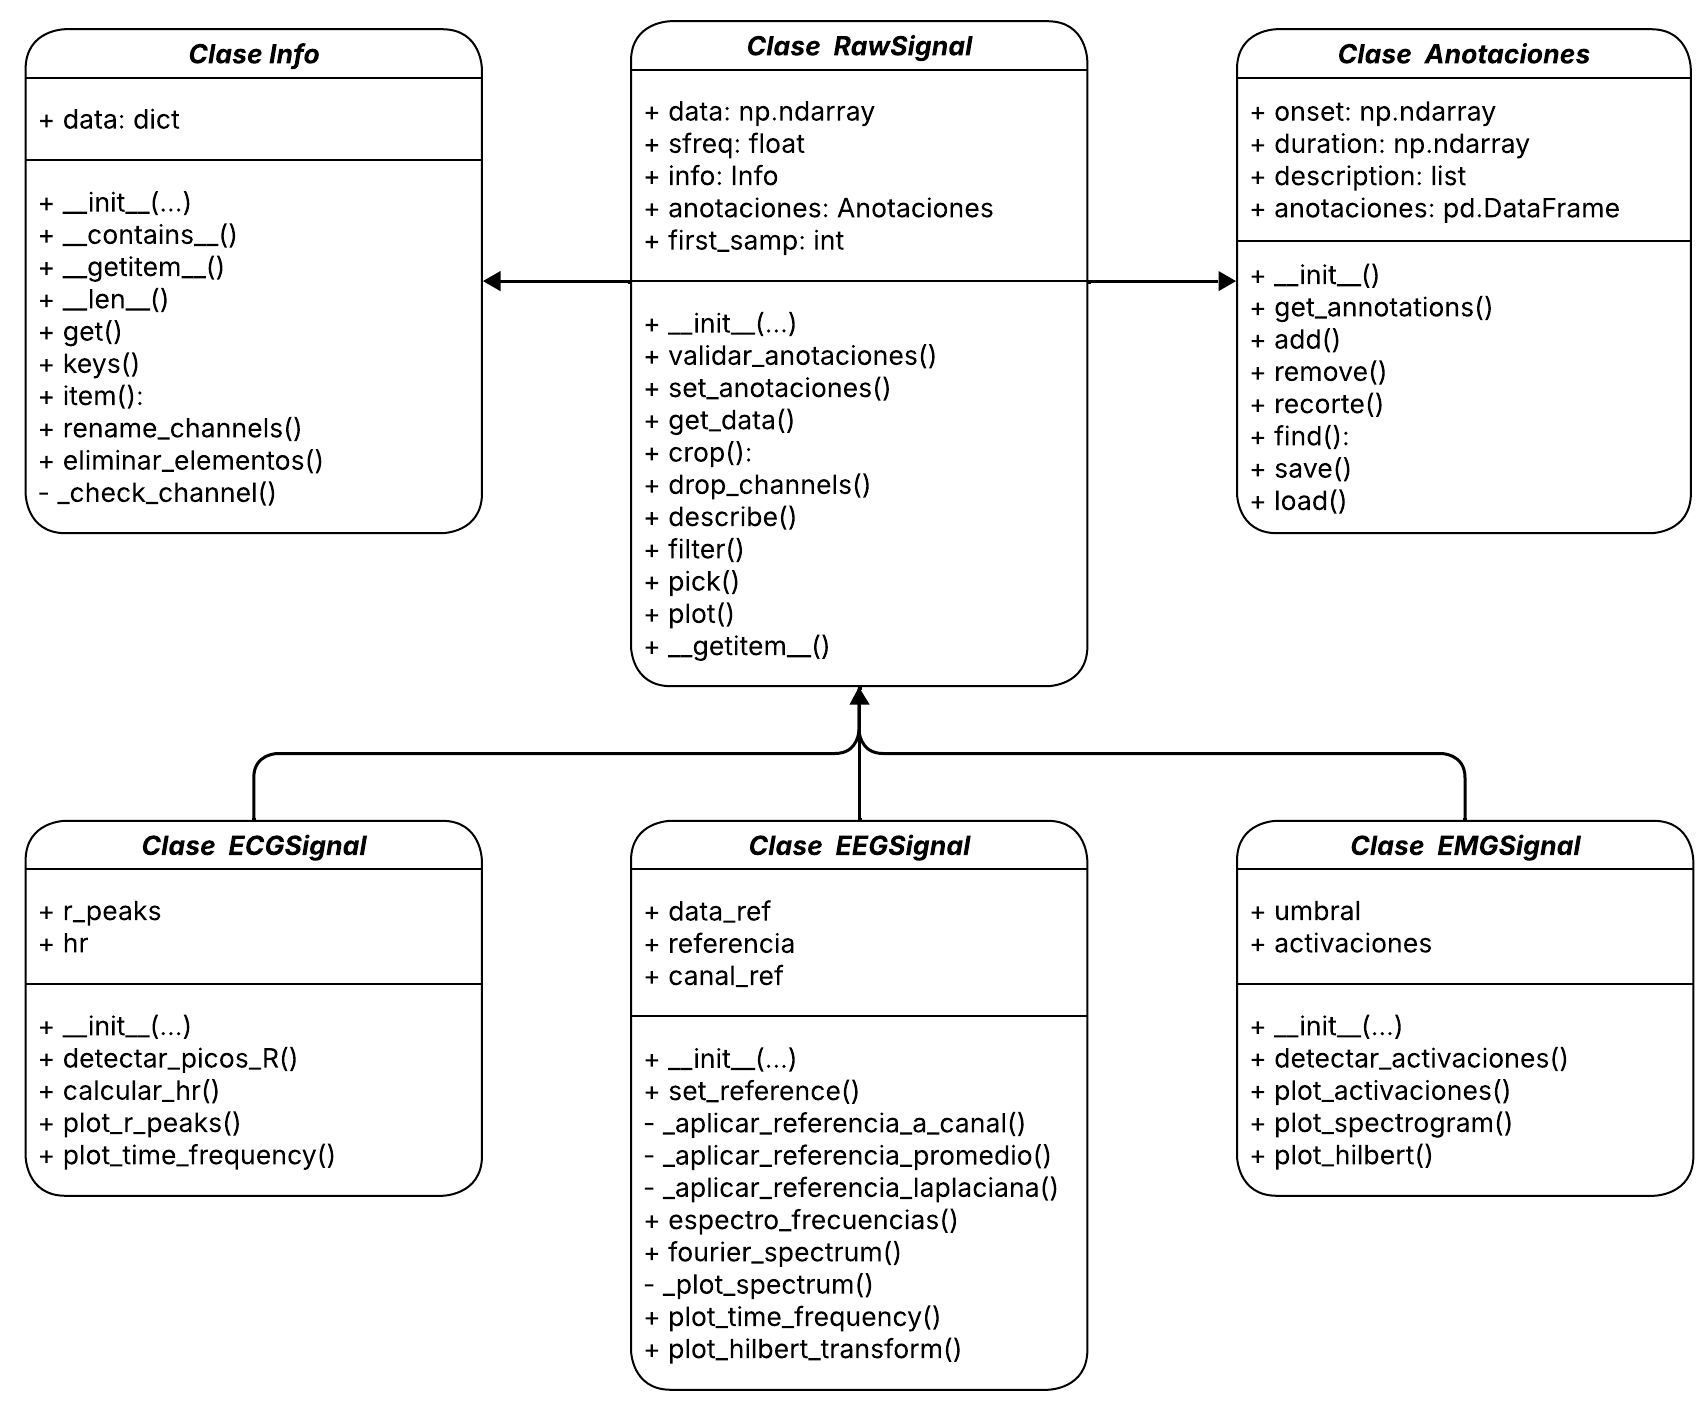

| ***Clase***      | ***Tipo de Objeto***      | ***Propósito Principal***                                 |
|------------------|--------------------------|-----------------------------------------------------------|
| Info             | Metadatos                | Almacena información sobre el registro y los canales      |
| Anotaciones      | Eventos                  | Gestiona eventos y anotaciones asociadas a la señal       |
| RawSignal        | Genérica                 | Manejo y procesamiento básico de señales fisiológicas     |
| EEGSignal        | EEG (Cerebro)            | Análisis espacial, espectral y referencia de EEG          |
| ECGSignal        | ECG (Corazón)            | Detección de picos R y cálculo de frecuencia cardíaca     |
| EMGSignal        | EMG (Músculo)            | Detección y análisis de activaciones musculares           |


> #### **Librerias utilizadas para la implementación**


In [212]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.signal import find_peaks, spectrogram, hilbert, spectrogram

In [211]:
from TIF import Info, Anotaciones, RawSignal, EEGSignal, ECGSignal, EMGSignal

## <span style="color: teal;">***Clase Info***</span>


> #### **Clase para almacenar información acerca del registro de datos.**

Por ejemplo:
- Nombre del experimentador
- Información del sujeto
- Nombres de los canales
- Tipos de canales
- Canales malos
- Descripción del experimento
- Frecuencia de muestreo
- Canales vecinos (solo para la señal de EEG)


#### ***Preparamos los datos necesarios***


Lista con nombres de los canales. De 1 a 62

In [213]:
canales = range(1,63)                            # Ejemplo para los nombre de los canales

nombre_canales = []
for canal in canales:
    nombre_canales.append(str(canal))

Tipos de canale

In [ ]:
tipos_canales = ["eeg"] * len(nombre_canales) 

sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

<p style="font-size: 22px; color: red;">
  <strong>Como vamos a usar una señal de EEG, cargamos algunos datos sobre cada canal. </strong>
</p>

In [183]:
import json

with open("../2. Datos Prueba/eeg/eeg_vecinos.json", "r") as f:
    vecinos = json.load(f)

### ***Generamos el objeto Info con los datos definidos***


In [184]:
info_eeg = Info(experimenter="Juan Acosta", subject_info=sujeto, ch_names=nombre_canales, 
        ch_types=tipos_canales, bads=None, description="Pruebita", fm=512, neighbors=vecinos)

In [185]:
print("Claves:", info_eeg.keys())
print()
print("Canales iniciales:", info_eeg.get("Nombre canales"))

Claves: ['Experimentador', 'Sujeto', 'Nombre canales', 'Tipo canales', 'Canales malos', 'Descripción', 'Frecuencia muestreo', 'Vecinos']

Canales iniciales: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62']


## <span style="color: teal;">***Clase Anotaciones***</span>


> #### **Almacena y gestiona información relacionada con eventos en registros fisiológicos. Permite la adición, eliminación y modificación de eventos.**


#### ***Cargamos las anotaciones desde un archivo CSV.***

In [186]:
anotaciones_eeg = Anotaciones(file="../2. Datos Prueba/eeg/eventos_ejemplo.csv")

<p style="font-size: 22px; color: red;">
  <strong>Podemos ver las anotaciones con el método 'get_annotations()'</strong>
</p>

In [187]:
anotaciones_eeg.get_annotations().head()

,Inicio,Duracion,Descripcion
0,37.548828,5,IZQUIERDA
1,54.048828,5,DERECHA
2,70.482422,5,DERECHA
3,88.632812,5,DERECHA
4,104.984375,5,IZQUIERDA


## <span style="color: teal;">***Clase RawSignal***</span>

> #### ***Clase para procesar señales fisiológicas***

> Utiliza la clase Info para almacenar información sobre la señal,
> y la clase Anotaciones para gestionar eventos asociados a la señal.

#### **Primero cargamos una señal. Usaremos la de EEG**

In [188]:
eeg_data = np.load("../2. Datos Prueba/eeg/eeg_signal.npy")

> #### ***Generamos el objeto RawSignal. Para eso le pasamos Info y Anotaciones que ya habiamos definido*** 

In [189]:
raw_signal = RawSignal(data=eeg_data, sfreq=512, info=info_eeg, anotaciones=anotaciones_eeg) 

## ***Los metodos disponibles en la clase RawSignal son:***
- `validar_anotaciones()`: Verifica que las anotaciones estén dentro del rango temporal de la señal.
  
- `set_anotaciones()`: Asocia o reemplaza el objeto 'Anotaciones' de la señal, validando que esté en rango.
  
- `get_data()`: Obtiene muestras de la señal en un rango dado.
  
- `crop()`: Recorta la señal en un rango de tiempo determinado.
  
- `drop_channels()`: Elimina uno o más canales a partir la señal.
  
- `describe()`: Genera un DataFrame con estadísticas descriptivas para cada canal de la señal.
  
- `filter()`: Aplica un filtro pasabanda y un filtro notch a la señal fisiológica.
  
- `pick()`: Retorna un subset de canales seleccionados.
  
- `plot()`: Grafica un segmento o toda la señal fisiológica.
  
- `__getitem__()`: Permite acceder a subconjuntos de la señal utilizando indexación personalizada.

## <span style="color: teal;">***Clase EEGSignal***</span>

> #### ***Clase para representar y analizar una señal de Electroencefalografía (EEG).***

<p style="font-size: 22px; color: red;">
  <strong>Instanciamos EEGSignal con el mismo objeto Info y Anotaciones que definimos anteriormente</strong>
</p>

In [243]:
eeg = EEGSignal(data=eeg_data, sfreq=512, info=info_eeg, anotaciones=anotaciones_eeg, first_samp=0)

### ***EEGSignal hereda de clase RawSignal***

#### ***Ademas de los que hereda, sus metodos adicionales son:***
- `set_reference()`: Cambia la referencia de la señal EEG. Opciones disponibles: 'canal', 'promedio' , 'laplaciano'.
  
- `_aplicar_referencia_a_canal()`:  Cambia la referencia de todos los canales a un canal específico.
  
- `_aplicar_referencia_promedio()`: Aplica una referencia promedio a la señal EEG.
  
- `_aplicar_referencia_laplaciana()`: Aplica un filtro espacial Laplaciano.
  
- `espectro_frecuencias()`: Calcula el espectro de potencia de uno o más canales con la transformada de Welch.
  
- `fourier_spectrum()`: Calcula la FFT (transformada de Fourier) de uno o más canales.
  
- `_plot_spectrum()`: Genera un gráfico individual del espectro para cada canal especificado.
  
- `plot_time_frequency()`: Calcula y grafica una representación tiempo-frecuencia para un canal específico de EEG.
  
- `plot_hilbert_transform()`: Calcula y grafica la transformada de Hilbert de uno o varios canales, mostrando la envolvente.

#### ***Cambiamos la referencia a Laplaciano con el método  `set_reference()`***

<p style="font-size: 22px; color: red;">
  <strong>Para aplicar la referencia Laplaciana, se utiliza el objeto Info que contiene la información de los canales cercanos a cada canal de la señal</strong>
</p>

In [246]:
ref_laplaciana = eeg.set_reference("laplaciano")
ref_laplaciana[0]

array([   0.3132112,    5.108612 ,   33.645447 , ..., -134.44702  ,
       -142.15036  , -153.25374  ], dtype=float32)

In [247]:
ref_promedio = eeg.set_reference(reference="promedio")
ref_promedio[0]

array([   1.493839,   26.415298,  181.00632 , ..., -131.14218 ,
       -136.10907 , -145.36543 ], dtype=float32)

#### ***Podemos filtrar la señal con el método  `filter()` que heredamos de RawSignal***

In [252]:
eeg_filtrada = eeg.filter(l_freq=0.1, h_freq=60, notch_freq=50)

In [251]:
type(eeg_filtrada)

TIF.EEGSignal

#### ***También la podemos recortar con el método `crop()`***

<p style="font-size: 22px; color: red;">
  <strong>Recortamos la señal entre el segundo 35 y 70</strong>
</p>

In [253]:
eeg_filtrada_recortada = eeg_filtrada.crop(tmin=35, tmax=70)

#### ***Ahora usamos el método `plot()` para graficar***

##### **Si habilitamos `show_anotaciones=True`, podemos ver las anotaciones en la gráfica.**

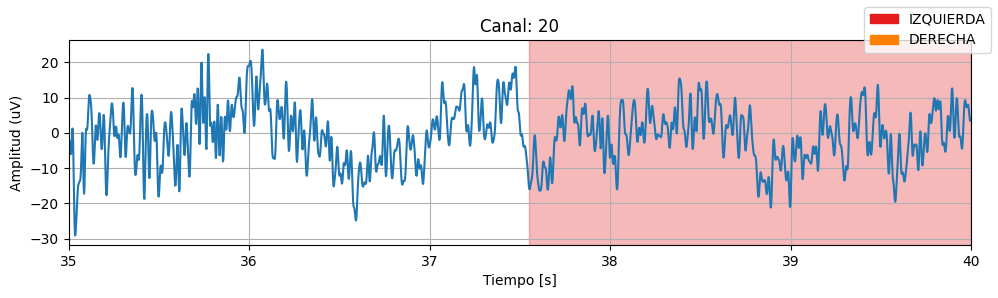

In [195]:
eeg_filtrada_recortada.plot(picks=["20"], duration=5, show_anotaciones=True)

#### ***Con el método `plot_hilbert_transform()` podemos calcular la transformada de hilbert, y ver la emvolvente de la señal***


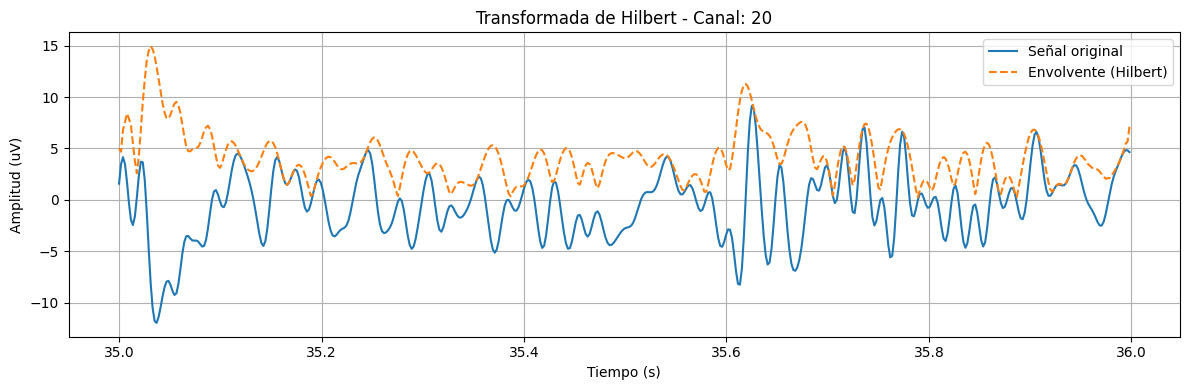

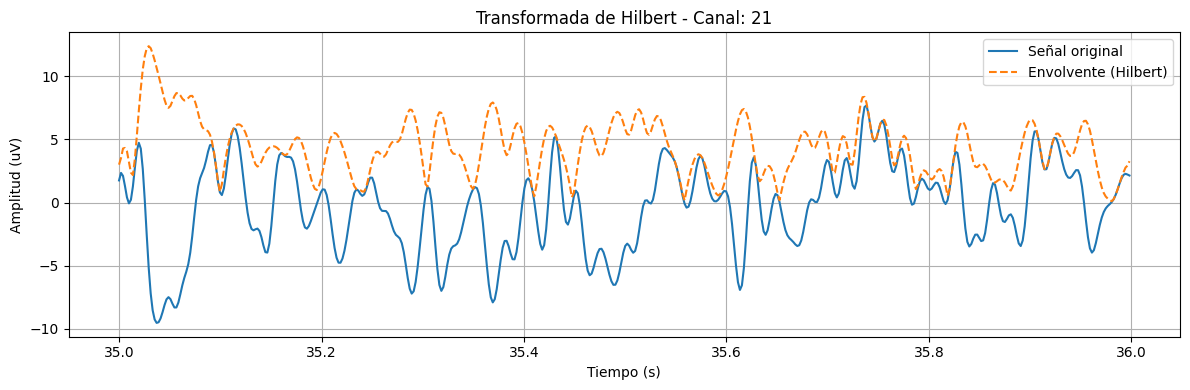

In [217]:
hilbert = eeg_filtrada_recortada.plot_hilbert_transform(picks=["20","21"], tmax=1)

## <span style="color: teal;">***Clase ECGSignal***</span>

> #### ***Clase especializada para el análisis de señales ECG.***


### ***ECGSignal hereda de la clase RawSignal***

#### ***Ademas de los que hereda, sus metodos adicionales son:***

- `detectar_r_peaks()`: Detecta los picos R en uno o más canales de una señal ECG.
  
- `calcular_hr()`:  Calcula la frecuencia cardíaca (heart rate) a partir de los picos R detectados.
  
- `plot_time_frequency()`: Calcula y grafica una representación tiempo-frecuencia para un canal específico de ECG.
  
- `plot_r_peaks()`: Grafica la señal de ECG con los picos R detectados superpuestos.

> #### ***Cargamos la señal de ECG***

In [218]:
ecg_data = np.load("../2. Datos Prueba/ecg/ecg.npy")*-1

<p style="font-size: 22px; color: red;">
  <strong>Generamos los objetos Info y Anotaciones para la señal</strong>
</p>

In [198]:
nombre_canales = ["1"]
    
tipos_canales = ["ecg"] * len(nombre_canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

info_ecg = Info(experimenter= "Flor", subject_info=sujeto, ch_names=nombre_canales, ch_types=tipos_canales,
                bads=None, description= "Prueba", fm= 512)

anotaciones_ecg = Anotaciones(file="../2. Datos Prueba/ecg/eventos_ecg.csv")

In [219]:
ecg = ECGSignal(data=ecg_data, sfreq=510, info=info_ecg, anotaciones=anotaciones_ecg)

#### ***Usamos el método  `detectar_r_peaks()` para obtener los picos de la señal***

<p style="font-size: 22px; color: red;">
  <strong>Podemos establecer el intervalo de tiempo en el que queremos buscar los picos. Por ejemplo, buscamos la cantidad de picos desde el segundo 5 al 15</strong>
</p>


In [221]:
picos = ecg.detectar_r_peaks(canales=["1"], start=5, end=15)
print(f"Picos R detectados: {len(picos[0])}")

Picos R detectados: 14


#### ***Ahora con `calcular_hr()` calculamos la frecuancia cardíaca***

In [223]:
fc = ecg.calcular_hr()
print(f"Frecuencia cardíaca promedio: {fc[0]:.2f} bpm")

Frecuencia cardíaca promedio: 82.51 bpm


> #### ***Filtramos la señal con el método heredado***

In [224]:
ecg_filtrada = ecg.filter(l_freq=1, h_freq=100, notch_freq=50)

#### ***Y por último, graficamos los picos detectados con `plot_r_peaks()`***

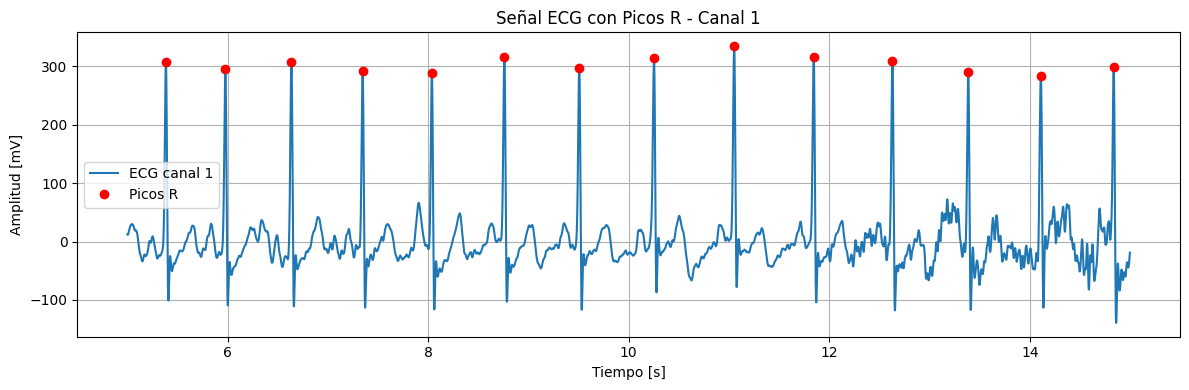

In [225]:
ecg_filtrada.plot_r_peaks(picks=["1"],start=5, end=15)

## <span style="color: teal;">***Clase EMGSignal***</span>


### ***EMGSignal hereda de la clase RawSignal***

#### ***Ademas de los que hereda, sus metodos adicionales son:***

- `detectar_activaciones()`: Detecta eventos de activación muscular en la señal EMG basados en un umbral.
  
- `plot_activaciones()`:  Grafica la señal EMG de un canal específico junto con las activaciones detectadas.
  
- `plot_spectrogram()`: Grafica el espectrograma de un canal específico de la señal EMG.
  
- `plot_hilbert()`: Calcula y grafica la transformada de Hilbert de uno o varios canales, mostrando la envolvente.

> #### ***Cargamos la señal de EMG***

In [226]:
emg_data = np.load("../2. Datos Prueba/emg/emg.npy")

<p style="font-size: 22px; color: red;">
  <strong>Generamos los objetos Info y Anotaciones para la señal</strong>
</p>

In [227]:
nombre_canales = ["1"]
    
tipos_canales = ["emg"] * len(nombre_canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

info_emg = Info(experimenter= "Joaquin", subject_info=sujeto, ch_names=nombre_canales, ch_types=tipos_canales,
                bads=None, description= "Prueba", fm= 512)

anotaciones_emg = Anotaciones(file="../2. Datos Prueba/emg/eventos_emg.csv")

In [228]:
emg = EMGSignal(emg_data, sfreq=512, info=info_emg, anotaciones=anotaciones_emg, umbral_microv=2)

> #### ***Filtramos la señal***

In [230]:
emg_filtrada = emg.filter(l_freq=1, h_freq=60, notch_freq=50)

#### ***Con `plot_activaciones()` podemos ver en que partes de la señal, la misma supera un determinado umbral***



<p style="font-size: 22px; color: red;">
  <strong>
  Ejemplo:
  Para 1 segundo de señal, queremos ver donde se supera el umbral de 5 uV</strong>
</p>

##### ***Internamente, este método primero utiliza `detectar_activaciones()` para identificar las activaciones, y luego las grafica.***

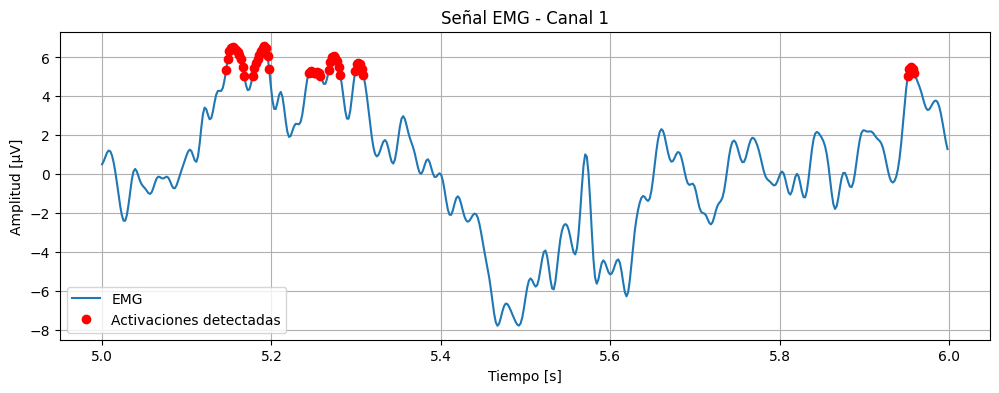

In [208]:
emg_filtrada.plot_activaciones(canal="1",start_time=5, end_time=6, umbral=5)

#### ***Con el método `plot_spectrogram()` podemos graficar el espectrograma de un canal específico de la señal EMG***


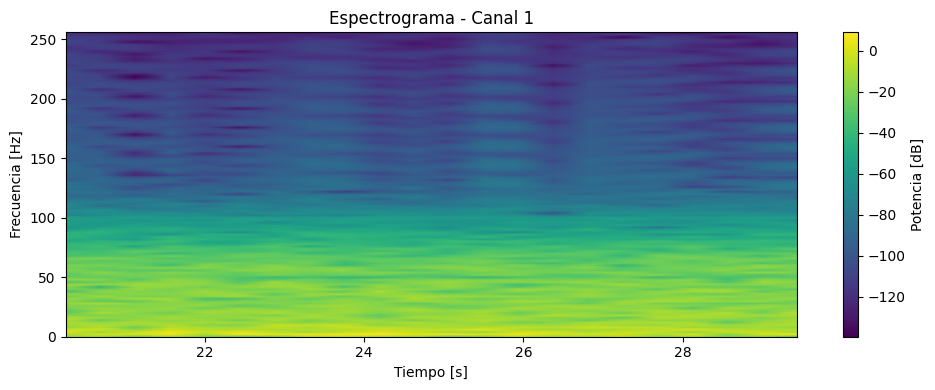

In [209]:
emg_filtrada.plot_spectrogram(canal="1", start_time=20, end_time=30)

## <span style="color: teal;">***Mejoras a futuro***</span>


- Ajustar los gráficos ya que en algunas ocasiones los ejes temporales relativos y absolutos no coinciden.
- El espectrograma se utiliza en las tres clases, unificarlo en un solo método en RawSignal.
- Las anotaciones que se cargan desde un archivo solo funcionan si se pasa una determinada estructura. 
  Mejorar la flexibilidad de este método para que pueda adaptarse a diferentes estructuras de archivos.
- Corregir el método que calcula la transformada de Fourier en la señal de EEG.

## <span style="color: teal;">***Conclusiones***</span>


- La librería desarrollada permitió integrar en una misma herramienta el procesamiento y análisis de señales EEG, EMG y ECG, utilizando una estructura basada en programación orientada a objetos. Esta organización facilitó la reutilización de código, la claridad del flujo de trabajo y la especialización según el tipo de señal.

- Cada clase derivada pudo construir sobre una base sólida (RawSignal), aprovechando métodos heredados como filter(), plot() o crop(), y al mismo tiempo ampliando la funcionalidad con análisis específicos como transformadas, activaciones musculares o detección de picos R.

- La librería fue validada a través de múltiples ejemplos funcionales, confirmando su utilidad para el análisis real de señales fisiológicas. Si bien el proyecto es ya operativo y funcional, quedan oportunidades claras de mejora para ampliar su robustez, compatibilidad y alcance.
